# SEIRS-SEI Malaria Model - Yearly Sequential Topic Calibration (lmfit)

Replaces the previous **grid-search** calibration with **lmfit differential evolution**.

**Scope: Any year range with available data.** The pipeline fits one year at a time.
Set `YEARS` to the desired range (e.g., [2017, 2018, 2019] or list(range(2017, 2024))).

For each year the parameters are calibrated **by topic in sequence**, fixing the
previous topics at their best values. The year is then simulated with the fully
fitted parameters and its **end-state is carried forward** as the initial
condition of the next year, except for **I_H**, which is reset to the first
observed `active_total` of that year (data) instead of the previous year's
simulated end-state.

## Per-year fitting order

1. **IC (2017 only)** - initial conditions: `S_H0_frac`, `E_H0_frac`, `I_M0_ratio`
   (`I_H0` is fixed from the first observed data point; `R_H0` is the residual of N).
2. **Humidity** - `H0`, `k`, `phi` (humidity-dependent mosquito survival).
3. **Human transmission** - `tau_H`, `gamma`, `omega`.
4. **Force of infection** - `b1` (mosquito acquisition), `b2` (human acquisition).
5. **Carrying capacity** - `M_prime` (mosquito habitat carrying capacity).

For 2018+ the IC step is skipped: the initial state is the end-state of the
previous year's simulation, with **I_H replaced by the first observed
`active_total` of that year**. Fitted parameter values are carried from each year
to the next as the starting guesses of the corresponding topic.

**Objective**: time-weighted MSE within each year (exponential weighting, early
months weighted higher - same scheme as the weighted humidity/human notebooks,
applied per year).

**Results**: saved to `lmfit_results.json`.

After the sequential pass, a **joint refinement** re-fits all of the year's
free parameters together (2017 IC fractions included), seeded from the
sequential solution, to undo the sub-optimality of fixing topics in order.

**Runtime**: 2017-only with `QUICK = False` is roughly 10-20 minutes
(sequential pass + joint refinement). A quick test mode (`QUICK = True`)
with a tiny DE budget is provided below.


## Step 1 - lmfit availability check

In [3]:
import importlib.util

if importlib.util.find_spec('lmfit') is None:
    print('lmfit is NOT installed in this environment.')
    print('Install it (e.g. with: pip install lmfit), then restart the kernel and re-run from the top.')
else:
    import lmfit
    print('lmfit is available:', lmfit.__version__)

lmfit is available: 1.3.2


## Step 2 - Imports and shared model code

`lmfit_optimization_shared.py` (in this folder) holds all data loading, the ODE
model, the per-year simulator and the lmfit objective builders.

In [5]:
from lmfit_optimization_shared import *
%matplotlib inline
import warnings, json, os, time
import pandas as pd
warnings.filterwarnings('ignore')

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


## Step 3 - Configuration

- `QUICK = True`  -> tiny DE budget, just to check the pipeline (~1 min for 2017).
- `QUICK = False` -> full run. 2017-only is ~10-20 min
  (sequential pass + Nelder-Mead refinement); all 7 years are ~1-2 h.

`max_nfev` caps the number of model evaluations per topic fit (lmfit ignores
`maxiter` for this method, so the budget is controlled here).

**Currently we only fit 2017.** Once 2017 is fitted well, extend `YEARS` to the
next year(s) and re-run the whole notebook.

Changes vs the first version, to improve the fit:
- **Milder weighting**: `decay_rate` 0.005 -> 0.0015 so the later months of the
  year actually contribute (year-end weight ~2.9 vs ~0.8 before).
- **Wider bounds**: `tau_H` up to 200 days, and looser 2017 IC bounds - both had
  hit their limits in the first run.
- **Larger DE budget**: `max_nfev` 300 -> 500 for the sequential topics.
- **Joint refinement**: after the per-topic sequential pass, all of the year's
  free parameters (IC included for 2017) are re-fit together with a local
  Nelder-Mead polish, seeded from the sequential solution.


In [7]:
QUICK = False

YEARS = [2017]
# Focus on 2017 first. Once it fits well, extend the list, e.g.:
# YEARS = [2017, 2018]
# YEARS = list(range(2017, 2024))  # all years

# Milder early emphasis: whole year contributes (start ~1.7x vs end of year).
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)
WEIGHT_KW['decay_rate'] = 0.0015

MAX_NFEV = 500
if QUICK:
    DE_SETTINGS = dict(seed=42, popsize=4, max_nfev=80, tol=0.01, polish=False)
else:
    DE_SETTINGS = dict(seed=42, popsize=6, max_nfev=MAX_NFEV, tol=0.01, polish=False)

# RESULTS_FILE is already provided by the shared module (points into this folder)
print('QUICK =', QUICK)
print('DE settings:', DE_SETTINGS)
print('Weight kw:', WEIGHT_KW)
print('Years:', YEARS)
print('Results file:', RESULTS_FILE)


QUICK = False
DE settings: {'seed': 42, 'popsize': 6, 'max_nfev': 500, 'tol': 0.01, 'polish': False}
Weight kw: {'weight_decay': 'exponential', 'decay_rate': 0.0015, 'initial_weight': 5.0, 'step_threshold': 365, 'step_later_weight': 1.0, 'inverse_scale': 365}
Years: [2017]
Results file: C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\lmfit_optimization\lmfit_results.json


## Step 4 - Baseline (default parameters, fixed 2017 ICs)

Simulates the full period with the default parameters and the fixed ode_models
initial conditions, to quantify the improvement after calibration.

In [9]:
print('Simulating baseline (default params, fixed 2017 ICs)...')
t0 = time.time()
base_traj, base_mse = run_baseline(years=YEARS, weight_kw=WEIGHT_KW)
print(f'done in {time.time()-t0:.1f}s')
print(f"{'Year':<6}{'Baseline wMSE':>16}")
for y in YEARS:
    print(f'{y:<6}{base_mse[y]:>16,.0f}')

Simulating baseline (default params, fixed 2017 ICs)...
done in 0.4s
Year     Baseline wMSE
2017           950,563


## Step 5 - Yearly sequential topic calibration

Runs lmfit differential evolution for every topic of every year, carrying the
best fitted values forward. If the notebook is interrupted, re-run from the top
with `resume=True` in the cell below to load the saved `lmfit_results.json`.

In [11]:
print('Running yearly sequential topic fitting (lmfit differential_evolution)...')
print('Order per year: [2017 only: IC] -> humidity -> human -> FoI -> M_prime')
print('Then a joint (Nelder-Mead) refinement over all free params of each year.')

t0 = time.time()
results, trajectories = run_yearly_fit(
    years=YEARS,
    de_settings=DE_SETTINGS,
    weight_kw=WEIGHT_KW,
    save_json=True,
    results_file=RESULTS_FILE,
    resume=False,
    refine=True,
    refine_method='nelder',
    refine_de_settings=dict(max_nfev=2 * MAX_NFEV),
    verbose=True,
)

elapsed = time.time() - t0
print(f'\nTotal elapsed: {elapsed:.1f}s (~{elapsed/60:.1f} min)')
print(f'Results saved to: {RESULTS_FILE}')

Running yearly sequential topic fitting (lmfit differential_evolution)...
Order per year: [2017 only: IC] -> humidity -> human -> FoI -> M_prime
Then a joint (Nelder-Mead) refinement over all free params of each year.

=== Fitting year 2017 ===
IC: S_H0_frac=0.3922, E_H0_frac=0.0010, I_M0_ratio=0.0335  (chisqr=4.435e+11, nfev=121)
  humidity: H0=31.73, k=0.3596, phi=0.1803  (chisqr=2.561e+11, nfev=90)
  human: tau_H=19.99, gamma=0.00676, omega=0.003436  (chisqr=1.66e+11, nfev=288)
  foi: b1=0.3165, b2=0.01428  (chisqr=8.88e+10, nfev=168)
  m_prime: M_prime=3.233e+05  (chisqr=8.843e+10, nfev=66)
  refine (12 params): S_H0_frac=0.3341, E_H0_frac=0.001059, I_M0_ratio=0.02748, H0=27.69, k=0.312, phi=0.1729, tau_H=19.95, gamma=0.006768, omega=0.07759, b1=0.335, b2=0.02438, M_prime=5.383e+04  (chisqr=1.405e+10, nfev=1001)
  -> year 2017: weighted MSE = 118543.5899

Saved results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\lmfit_optimization\lmfit_results.json

Total elaps

  refine (12 params): S_H0_frac=0.7404, E_H0_frac=0.001064, I_M0_ratio=0.0005008, H0=20.21, k=0.121, phi=0.4998, tau_H=197.9, gamma=0.00177, omega=0.01423, b1=0.04171, b2=0.07066, M_prime=2.622e+05  (chisqr=3.101e+09, nfev=1001)
  -> year 2017: weighted MSE = 55684.4477

Saved results to /mnt/c/Users/rapha/Study_on_malaria_dynamics_v2/models/seirs_sei/lmfit_optimization/lmfit_results.json

Total elapsed: 252.8s (~4.2 min)
Results saved to: /mnt/c/Users/rapha/Study_on_malaria_dynamics_v2/models/seirs_sei/lmfit_optimization/lmfit_results.json


## Step 6 - Results summary

In [13]:
rows = []
for y in YEARS:
    yr = results[str(y)]
    for topic in ['IC', 'humidity', 'human', 'foi', 'm_prime', 'refine']:
        if topic in yr:
            entry = {'year': y, 'topic': topic}
            entry.update(yr[topic])
            rows.append(entry)

tbl = pd.DataFrame(rows)
if 'wMSE' in tbl.columns:
    tbl['wMSE'] = tbl['wMSE'].astype(float).round(0)
print('Per-topic fit summary (wMSE = sqrt(chisqr) at that stage):')
print(tbl.to_string(index=False))

print('\nFinal per-year weighted MSE (all topics fitted):')
print(f"{'Year':<6}{'Calibrated':>16}{'Baseline':>16}")
for y in YEARS:
    print(f'{y:<6}{results[str(y)]["weighted_mse"]:>16,.0f}{base_mse[y]:>16,.0f}')

Per-topic fit summary (wMSE = sqrt(chisqr) at that stage):
 year    topic  S_H0_frac  E_H0_frac  I_M0_ratio       chisqr     wMSE  nfev  success        H0        k      phi     tau_H    gamma    omega       b1       b2       M_prime
 2017       IC   0.392170   0.001000    0.033497 4.434788e+11 665942.0   121     True       NaN      NaN      NaN       NaN      NaN      NaN      NaN      NaN           NaN
 2017 humidity        NaN        NaN         NaN 2.560734e+11 506037.0    90     True 31.728080 0.359627 0.180322       NaN      NaN      NaN      NaN      NaN           NaN
 2017    human        NaN        NaN         NaN 1.659907e+11 407420.0   288     True       NaN      NaN      NaN 19.989103 0.006760 0.003436      NaN      NaN           NaN
 2017      foi        NaN        NaN         NaN 8.879781e+10 297990.0   168     True       NaN      NaN      NaN       NaN      NaN      NaN 0.316523 0.014284           NaN
 2017  m_prime        NaN        NaN         NaN 8.843358e+10 297378.0 

## Step 7 - Visualization: model vs observed

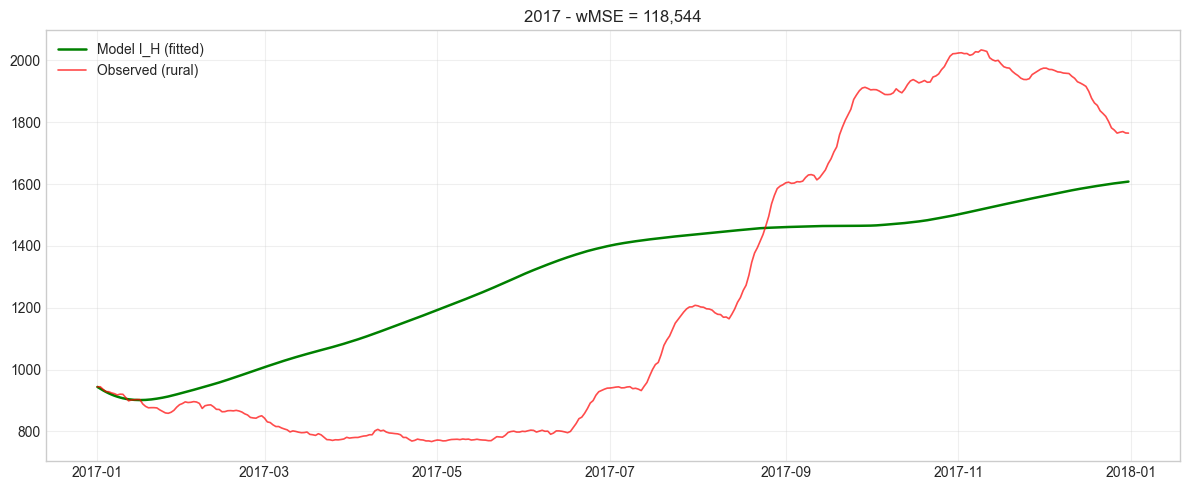

In [15]:
n_years = len(YEARS)
if n_years > 1:
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))
    axes = axes.ravel()
    for i, y in enumerate(YEARS):
        ax = axes[i]
        dates, IH = trajectories[y]
        obs = observed_for_year(y)
        ax.plot(pd.to_datetime(dates), IH, 'g-', linewidth=1.8, label='Model I_H (fitted)')
        ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, linewidth=1.2, label='Observed (rural)')
        ax.set_title(f'{y} - wMSE = {results[str(y)]["weighted_mse"]:,.0f}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    ax = axes[-1]
    all_dates, all_IH = [], []
    for y in YEARS:
        d, ih = trajectories[y]
        all_dates.extend(d)
        all_IH.extend(ih)
    ax.plot(pd.to_datetime(all_dates), all_IH, 'g-', linewidth=1.5, label='Model I_H (fitted)')
    ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', alpha=0.7, label='Observed (rural)')
    ax.set_title('Full 2017-2023 period')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
else:
    y = YEARS[0]
    fig, ax = plt.subplots(figsize=(12, 5))
    dates, IH = trajectories[y]
    obs = observed_for_year(y)
    ax.plot(pd.to_datetime(dates), IH, 'g-', linewidth=1.8, label='Model I_H (fitted)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, linewidth=1.2, label='Observed (rural)')
    ax.set_title(f'{y} - wMSE = {results[str(y)]["weighted_mse"]:,.0f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8 - Fitted parameter evolution across years

In [17]:
params_of_interest = ['M_prime', 'tau_H', 'gamma', 'omega', 'b1', 'b2', 'H0', 'k', 'phi']

if len(YEARS) > 1:
    fig, axes = plt.subplots(3, 3, figsize=(16, 11))
    axes = axes.ravel()
    for ax, name in zip(axes, params_of_interest):
        vals = [results[str(y)]['params'][name] for y in YEARS]
        ax.plot(YEARS, vals, 'o-', linewidth=1.5)
        ax.set_title(name)
        ax.set_xlabel('year')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    y = YEARS[0]
    print(f'Fitted parameters for {y}:')
    for name in params_of_interest:
        print(f'  {name:<10} = {results[str(y)]["params"][name]:.6g}')

Fitted parameters for 2017:
  M_prime    = 53826
  tau_H      = 19.9508
  gamma      = 0.00676763
  omega      = 0.0775941
  b1         = 0.334982
  b2         = 0.0243832
  H0         = 27.688
  k          = 0.311988
  phi        = 0.172876


## Notes

- Results are saved to `lmfit_results.json`. To resume a previous run (load the
  saved file instead of re-fitting), call `run_yearly_fit(resume=True, ...)`.
- `success=False` in the per-topic/refine summary just means the DE evaluation
  budget (`max_nfev`) was reached before convergence; the reported parameters are
  still the best found within that budget.
- `chisqr` follows the lmfit convention for a scalar objective (chisqr = wMSE^2);
  the `wMSE` column shows sqrt(chisqr), i.e. the weighted MSE at that stage.
- The weighted MSE uses exponential decay within each year (decay_rate=0.0015,
  i.e. a mild early emphasis): January counts ~1.7x more than December, so the
  whole year contributes to the fit.
- The `refine` row is the joint re-fit (local Nelder-Mead) of all of that
  year's free parameters (IC included for 2017) seeded from the sequential
  solution; the final per-year `weighted_mse` and the plotted trajectory use
  these refined parameters.
